# Polymarket — `polymarket_markets_rich.csv`

Exploratory summary of the exported Polymarket markets table: schema, activity flags, volume/liquidity, implied prices from `outcomePrices`, and a few plots.

Use this repo’s `.venv` as the Jupyter kernel (same as `notebooks/week6_implementation.ipynb`).

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Resolve CSV: notebook lives at repo root; fall back to data/
_here = Path.cwd()
for candidate in (_here / "polymarket_markets_rich.csv", _here / "data" / "polymarket_markets_rich.csv"):
    if candidate.is_file():
        DATA = candidate
        break
else:
    raise FileNotFoundError("polymarket_markets_rich.csv not found next to notebook or under data/")

print(DATA.resolve())

C:\Users\Patrick\Documents\Python\STAT-4830-NAPPERS-project\polymarket_markets_rich.csv


In [2]:
df = pd.read_csv(DATA, low_memory=False)
df.shape

(500, 92)

## Schema & missingness

The export mixes scalars and JSON blobs (`outcomes`, `outcomePrices`, `events`, etc.).

In [3]:
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)
df.head(3)

,id,question,conditionId,slug,resolutionSource,endDate,liquidity,startDate,image,icon,description,outcomes,outcomePrices,volume,active,...,pendingDeployment,deploying,deployingTimestamp,rfqEnabled,holdingRewardsEnabled,feesEnabled,requiresTranslation,feeType,oneDayPriceChange,oneWeekPriceChange,oneHourPriceChange,negRiskMarketID,umaResolutionStatus,gameStartTime,eventStartTime
0,540816,Russia-Ukraine Ceasefire before GTA VI?,0x9c1a953fe92c8357f1b646ba25d983aa83e90c525992...,russia-ukraine-ceasefire-before-gta-vi-554,NaN,2026-07-31T12:00:00Z,53602.7980,2025-05-02T15:48:00.174Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,"This market will resolve to ""Yes"" if if there...","[""Yes"", ""No""]","[""0.535"", ""0.465""]",1.412740e+06,True,...,False,False,2025-05-02T15:47:04.719613Z,False,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,540817,New Rihanna Album before GTA VI?,0x1fad72fae204143ff1c3035e99e7c0f65ea8d5cd9bd1...,new-rhianna-album-before-gta-vi-926,NaN,2026-07-31T12:00:00Z,38073.9377,2025-05-02T15:48:10.582Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,"This market will resolve to ""Yes"" if Rihanna o...","[""Yes"", ""No""]","[""0.595"", ""0.405""]",6.795250e+05,True,...,False,False,2025-05-02T15:47:04.727292Z,False,False,False,False,NaN,-0.010,NaN,NaN,NaN,NaN,NaN,NaN
2,540818,New Playboi Carti Album before GTA VI?,0x50ddb9cd80d5c271664a2ebb7fcaed1d0a148d82c8e8...,new-playboi-carti-album-before-gta-vi-421,NaN,2026-07-31T12:00:00Z,28864.7543,2025-05-02T15:48:10.837Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,"This market will resolve to ""Yes"" if Playboi C...","[""Yes"", ""No""]","[""0.605"", ""0.395""]",7.138603e+05,True,...,False,False,2025-05-02T15:47:04.718487Z,False,False,False,False,NaN,0.015,-0.03,NaN,NaN,NaN,NaN,NaN


In [4]:
list(df.columns)

['id',
 'question',
 'conditionId',
 'slug',
 'resolutionSource',
 'endDate',
 'liquidity',
 'startDate',
 'image',
 'icon',
 'description',
 'outcomes',
 'outcomePrices',
 'volume',
 'active',
 'closed',
 'marketMakerAddress',
 'createdAt',
 'updatedAt',
 'new',
 'featured',
 'submitted_by',
 'archived',
 'resolvedBy',
 'restricted',
 'groupItemTitle',
 'groupItemThreshold',
 'questionID',
 'enableOrderBook',
 'orderPriceMinTickSize',
 'orderMinSize',
 'volumeNum',
 'liquidityNum',
 'endDateIso',
 'startDateIso',
 'hasReviewedDates',
 'volume24hr',
 'volume1wk',
 'volume1mo',
 'volume1yr',
 'clobTokenIds',
 'umaBond',
 'umaReward',
 'volume24hrClob',
 'volume1wkClob',
 'volume1moClob',
 'volume1yrClob',
 'volumeClob',
 'liquidityClob',
 'customLiveness',
 'acceptingOrders',
 'negRisk',
 'negRiskRequestID',
 'events',
 'ready',
 'funded',
 'acceptingOrdersTimestamp',
 'cyom',
 'competitive',
 'pagerDutyNotificationEnabled',
 'approved',
 'clobRewards',
 'rewardsMinSize',
 'rewardsMaxSp

In [5]:
miss = (df.isna().mean() * 100).sort_values(ascending=False)
miss[miss > 0].head(25)

resolutionSource       100.0
feeType                100.0
eventStartTime          99.8
gameStartTime           99.8
umaResolutionStatus     99.8
seriesColor             98.0
marketMakerAddress      97.4
oneHourPriceChange      78.8
clobRewards             71.4
oneDayPriceChange       48.2
oneWeekPriceChange      27.2
oneMonthPriceChange     13.2
customLiveness          11.0
bestBid                 10.6
volume1yr                6.6
volume24hr               6.6
volume1mo                6.6
volume1wk                6.6
volume1yrClob            6.6
volume1moClob            6.6
volume24hrClob           6.6
volume1wkClob            6.6
negRiskRequestID         5.0
negRiskMarketID          5.0
showGmpSeries            2.2
dtype: float64

## Activity & flags

In [6]:
for col in ["active", "closed", "featured", "archived", "restricted", "acceptingOrders"]:
    if col in df.columns:
        print(col)
        print(df[col].value_counts(dropna=False))
        print()

active
active
True    500
Name: count, dtype: int64

closed
closed
False    500
Name: count, dtype: int64

featured
featured
False    498
True       2
Name: count, dtype: int64

archived
archived
False    500
Name: count, dtype: int64

restricted
restricted
True    500
Name: count, dtype: int64

acceptingOrders
acceptingOrders
True    500
Name: count, dtype: int64



## Volume & liquidity (numeric)

`volumeNum` / `liquidityNum` align with string `volume` / `liquidity` in the sample; we use the `*Num` columns for math.

In [7]:
num_cols = [
    "volumeNum",
    "liquidityNum",
    "volume24hr",
    "volume1wk",
    "volume1mo",
    "spread",
    "competitive",
    "lastTradePrice",
    "bestBid",
    "bestAsk",
]
num_cols = [c for c in num_cols if c in df.columns]
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
volumeNum,496.0,6.574740e+06,9.365866e+06,4552.434399,319416.985432,2.022209e+06,9.381324e+06,4.486464e+07
liquidityNum,500.0,4.551636e+05,6.032810e+05,695.404740,45045.615600,1.305090e+05,6.351254e+05,2.750017e+06
volume24hr,467.0,7.713466e+04,1.724880e+05,5.000000,2030.975274,1.447925e+04,7.005213e+04,1.820256e+06
volume1wk,467.0,5.657487e+05,9.713284e+05,5.000000,24477.264698,1.181126e+05,7.975233e+05,1.329524e+07
volume1mo,467.0,2.291804e+06,2.830992e+06,1959.307274,203026.631831,9.266121e+05,3.840791e+06,1.911852e+07
spread,500.0,4.414000e-03,1.278207e-02,0.001000,0.001000,1.000000e-03,3.000000e-03,1.830000e-01
competitive,500.0,8.287226e-01,5.030066e-02,0.800320,0.802238,8.054304e-01,8.258248e-01,9.999750e-01
lastTradePrice,500.0,7.165800e-02,1.662211e-01,0.001000,0.003000,9.000000e-03,4.000000e-02,9.930000e-01
bestBid,447.0,7.825280e-02,1.717389e-01,0.001000,0.004000,1.000000e-02,5.000000e-02,9.920000e-01
bestAsk,500.0,7.437200e-02,1.684407e-01,0.001000,0.004000,1.000000e-02,4.300000e-02,9.930000e-01


In [8]:
sort_col = "volumeNum" if "volumeNum" in df.columns else "volume"
top = df.nlargest(15, sort_col)[
    [c for c in ["id", "question", sort_col, "liquidityNum", "active", "closed", "endDateIso"] if c in df.columns]
]
top

,id,question,volumeNum,liquidityNum,active,closed,endDateIso
146,559684,Will Chelsea Clinton win the 2028 Democratic p...,4.486464e+07,6.476860e+05,True,False,2028-11-07
149,559687,Will Oprah Winfrey win the 2028 Democratic pre...,4.396495e+07,5.556845e+05,True,False,2028-11-07
181,561251,Will LeBron James win the 2028 US Presidential...,4.368578e+07,1.571074e+06,True,False,2028-11-07
150,559688,Will Andrew Yang win the 2028 Democratic presi...,4.296977e+07,1.199969e+06,True,False,2028-11-07
141,559679,Will Bernie Sanders win the 2028 Democratic pr...,4.014740e+07,2.289825e+06,True,False,2028-11-07
143,559681,Will LeBron James win the 2028 Democratic pres...,3.902184e+07,1.904081e+06,True,False,2028-11-07
177,561247,Will Tim Walz win the 2028 US Presidential Ele...,3.881242e+07,1.690208e+06,True,False,2028-11-07
139,559677,Will Hillary Clinton win the 2028 Democratic p...,3.815954e+07,1.617402e+06,True,False,2028-11-07
145,559683,Will George Clooney win the 2028 Democratic pr...,3.762782e+07,7.269311e+05,True,False,2028-11-07
128,559666,Will Tim Walz win the 2028 Democratic presiden...,3.728305e+07,1.305060e+06,True,False,2028-11-07


## Implied prices from `outcomePrices`

Parse JSON; take the first listed price as `implied_0` (usually “Yes” for binary markets when outcomes are `["Yes","No"]`).

In [9]:
def first_outcome_price(raw):
    if pd.isna(raw) or raw == "":
        return np.nan
    try:
        arr = json.loads(raw)
        return float(arr[0]) if arr else np.nan
    except (json.JSONDecodeError, TypeError, ValueError, IndexError):
        return np.nan


if "outcomePrices" in df.columns:
    df["implied_0"] = df["outcomePrices"].map(first_outcome_price)
    display(df["implied_0"].describe())
else:
    print("No outcomePrices column")

count    500.000000
mean       0.072165
std        0.166183
min        0.000500
25%        0.003500
50%        0.008500
75%        0.041500
max        0.992500
Name: implied_0, dtype: float64

## Event titles (from `events` JSON)

First event’s `title` when present.

In [10]:
def first_event_title(raw):
    if pd.isna(raw) or raw == "":
        return np.nan
    try:
        evs = json.loads(raw)
        if not evs:
            return np.nan
        return evs[0].get("title")
    except (json.JSONDecodeError, TypeError, AttributeError):
        return np.nan


if "events" in df.columns:
    df["event_title"] = df["events"].map(first_event_title)
    display(df["event_title"].value_counts(dropna=True).head(15))
else:
    print("No events column")

event_title
Augusta National Invitational - Winner               59
2026 FIFA World Cup Winner                           48
Democratic Presidential Nominee 2028                 44
Presidential Election Winner 2028                    36
Republican Presidential Nominee 2028                 35
2026 NHL Stanley Cup Champion                        28
NBA MVP                                              22
2026 NBA Champion                                    20
Colombia Presidential Election                       18
 Colombia Presidential Election 1st round winner?    17
Next James Bond actor?                               15
English Premier League – 2nd Place                   14
English Premier League – 3rd Place                   14
NBA Rookie of the Year                               13
NBA Eastern Conference Champion                      10
Name: count, dtype: int64

## Plots

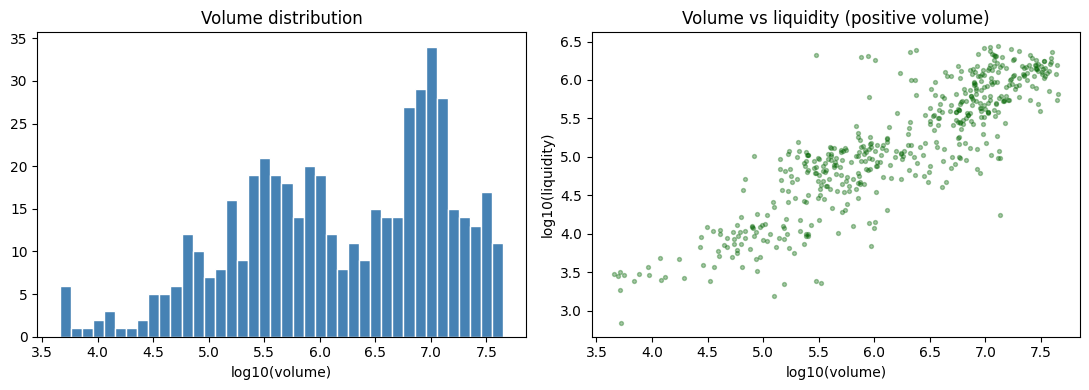

In [11]:
vcol = "volumeNum" if "volumeNum" in df.columns else "volume"
lcol = "liquidityNum" if "liquidityNum" in df.columns else "liquidity"

v = pd.to_numeric(df[vcol], errors="coerce").clip(lower=0)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax0, ax1 = axes
ax0.hist(np.log10(v.replace(0, np.nan).dropna()), bins=40, color="steelblue", edgecolor="white")
ax0.set_xlabel("log10(volume)")
ax0.set_title("Volume distribution")

if lcol in df.columns:
    liq = pd.to_numeric(df[lcol], errors="coerce").clip(lower=0)
    m = v > 0
    ax1.scatter(np.log10(v[m]), np.log10(liq[m]), s=8, alpha=0.35, c="darkgreen")
    ax1.set_xlabel("log10(volume)")
    ax1.set_ylabel("log10(liquidity)")
    ax1.set_title("Volume vs liquidity (positive volume)")
else:
    ax1.set_visible(False)

plt.tight_layout()
plt.show()

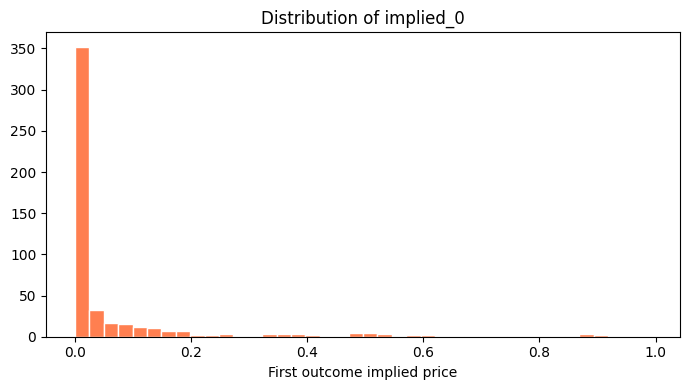

In [12]:
if "implied_0" in df.columns and df["implied_0"].notna().any():
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(df["implied_0"].dropna(), bins=40, color="coral", edgecolor="white")
    ax.set_xlabel("First outcome implied price")
    ax.set_title("Distribution of implied_0")
    plt.tight_layout()
    plt.show()

## Resolution timing

End dates as parsed datetimes when `endDateIso` or `endDate` is available.

In [13]:
ed = None
if "endDateIso" in df.columns and df["endDateIso"].notna().any():
    ed = pd.to_datetime(df["endDateIso"], utc=True, errors="coerce")
elif "endDate" in df.columns:
    ed = pd.to_datetime(df["endDate"], utc=True, errors="coerce")

if ed is not None:
    print(ed.dt.year.value_counts().sort_index())
else:
    print("No end date column parsed")

endDateIso
2025      7
2026    376
2028    117
Name: count, dtype: int64
